import libraries and according to the usability in code

In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,classification_report,roc_auc_score

The dataset is publically available on the Kaggle website, and it is from an ongoing cardiovascular study on residents of the town of Framingham, Massachusetts. The classification goal is to predict whether the patient has 10-year risk of future coronary heart disease (CHD).The dataset provides the patients’ information. It includes over 4,000 records and 15 attributes.
Variables
Each attribute is a potential risk factor. There are both demographic, behavioral and medical risk factors.

Demographic:
• Sex: male or female(Nominal)

• Age: Age of the patient;(Continuous - Although the recorded ages have been truncated to whole numbers, the concept of age is continuous)
Behavioral

• Current Smoker: whether or not the patient is a current smoker (Nominal)

• Cigs Per Day: the number of cigarettes that the person smoked on average in one day.(can be considered continuous as one can have any number of cigarettes, even half a cigarette.)
Medical( history)

• BP Meds: whether or not the patient was on blood pressure medication (Nominal)

• Prevalent Stroke: whether or not the patient had previously had a stroke (Nominal)

• Prevalent Hyp: whether or not the patient was hypertensive (Nominal)

• Diabetes: whether or not the patient had diabetes (Nominal)
Medical(current)

• Tot Chol: total cholesterol level (Continuous)

• Sys BP: systolic blood pressure (Continuous)

• Dia BP: diastolic blood pressure (Continuous)

• BMI: Body Mass Index (Continuous)

• Heart Rate: heart rate (Continuous - In medical research, variables such as heart rate though in fact discrete, yet are considered continuous because of large number of possible values.)

• Glucose: glucose level (Continuous)

Predict variable (desired target)

• 10 year risk of coronary heart disease CHD (binary: “1”, means “Yes”, “0” means “No”)
Logistic Regression

In [17]:
df = pd.read_csv("/content/framingham.csv")
df.sample(5)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
2499,0,46,2.0,1,15.0,0.0,0,0,0,232.0,115.0,70.0,25.18,75.0,59.0,1
1866,0,42,3.0,0,0.0,0.0,0,0,0,252.0,102.0,72.5,22.85,60.0,NaN,0
1848,0,47,1.0,0,0.0,0.0,0,0,0,289.0,126.5,84.0,21.71,69.0,70.0,0
891,1,35,2.0,0,0.0,0.0,0,0,0,290.0,108.0,72.0,22.91,55.0,84.0,0
1770,0,47,3.0,0,0.0,0.0,0,1,0,250.0,167.0,96.5,23.79,65.0,NaN,0


In [18]:
df.isna().sum()

,0
male,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


In [19]:
df.shape

(4238, 16)

In [30]:
for a in df.columns:
    if df[a].isna().sum() > 0:   #  Check NaN values in that column
        if df[a].dtype in ['float64', 'int64']:   #  Numeric column
            df[a].fillna(df[a].mean(), inplace=True)
        else:   #  Categorical column
            df[a].fillna(df[a].mode()[0], inplace=True)


/tmp/ipython-input-1922686857.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[a].fillna(df[a].mean(), inplace=True)


In [31]:
df.isna().sum()

,0
male,0
age,0
education,0
currentSmoker,0
cigsPerDay,0
BPMeds,0
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,0


In [32]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.00000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.02963,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.007075,0.500024,11.879230,0.16852,0.076587,0.462763,0.158316,44.326453,22.038097,11.910850,4.070953,12.025177,22.836603,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.080000,68.000000,72.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.410000,75.000000,80.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.00000,0.000000,1.000000,0.000000,262.000000,144.000000,89.875000,28.037500,83.000000,85.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.00000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [33]:
numerical_features = ['male','age','education','currentSmoker','prevalentStroke','prevalentHyp','diabetes','sysBP','diaBP','TenYearCHD']
df_num = df[numerical_features]

In [34]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_num)

In [35]:
df_scaled = pd.DataFrame(df_scaled, columns=numerical_features)
df_scaled.head()

,male,age,education,currentSmoker,prevalentStroke,prevalentHyp,diabetes,sysBP,diaBP,TenYearCHD
0,1.153192,-1.234951,2.007088,-0.988271,-0.077033,-0.671101,-0.162477,-1.195907,-1.082625,-0.423305
1,-0.867158,-0.418257,0.020905,-0.988271,-0.077033,-0.671101,-0.162477,-0.515187,-0.158988,-0.423305
2,1.153192,-0.184916,-0.972187,1.011868,-0.077033,-0.671101,-0.162477,-0.220209,-0.242955,-0.423305
3,-0.867158,1.331800,1.013996,1.011868,-0.077033,1.490089,-0.162477,0.800871,1.016549,2.362360
4,-0.867158,-0.418257,1.013996,1.011868,-0.077033,-0.671101,-0.162477,-0.106755,0.092912,-0.423305


In [36]:
X = df.drop(columns = ['diabetes'])
y = df['diabetes']

In [37]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [38]:
model = LogisticRegression()
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [40]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

In [45]:
accuracy = accuracy_score(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)
report = classification_report(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)


In [46]:
print("Model Evaluation Metrics:")
print(f"Accuracy       : {accuracy:.4f}")
print(f"ROC-AUC Score  : {roc_auc:.4f}")
print("\nClassification Report:\n", report)

Model Evaluation Metrics:
Accuracy       : 0.9835
ROC-AUC Score  : 0.8106

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       824
           1       0.86      0.50      0.63        24

    accuracy                           0.98       848
   macro avg       0.92      0.75      0.81       848
weighted avg       0.98      0.98      0.98       848



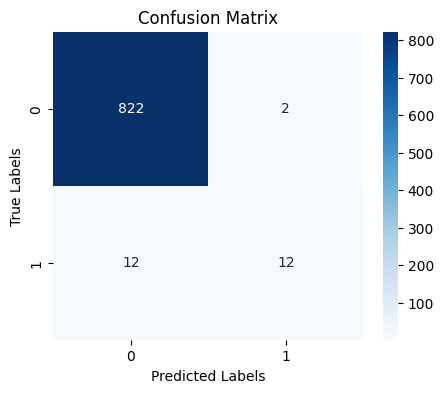

In [49]:
#confusion_matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()
